In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
import control as ct

from matplotlib import pyplot as plt
from scipy.linalg import block_diag
from sklearn.model_selection import train_test_split

import kind
import utils_data
import utils_nn

In [2]:
class linear_system:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.matmul(x, torch.transpose(self.matrix, 0, 1))


### Defining a reward function

In [3]:
class quadratic_fun:
    def __init__(self, matrix):
        self.matrix = matrix

    def __call__(self, x):
        return torch.einsum('btc,cd,btd->bt', x, self.matrix, x).unsqueeze(-1)

state_ndim = 1
action_ndim = 1

state_cost = 1.0 * torch.eye(state_ndim)
action_cost = 0.01 * torch.eye(action_ndim)

reward_fun = quadratic_fun(torch.block_diag(-state_cost, -action_cost))

### Discounted return function

In [4]:
class montecarlo_fun:
    def __init__(self, discount=0.95):
        self.gamma = discount

    def __call__(self, reward):
        return torch.sum(torch.stack([self.gamma**j * r for j, r in enumerate(reward)]), dim=1, keepdim=True)

gamma = 0.96
return_fun = montecarlo_fun(gamma)

In [5]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-rl-policy-eval',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '200',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 6, "cos": 6}',
        '--fun_trans', '{"data": 10}',
    ]
)

In [6]:
dataset = utils_data.dataset_factory().create_dataset(args)
train_loader, valid_loader, test_loader = dataset.load(data_type='mixed')

In [7]:
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=72, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1728, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=36, out_features=12, bias=False)
    (mod_mean): Linear(in_features=12, out_features=12, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=864, bia

In [8]:
def evaluate_policy(sa, model, args, value_fun, gamma):

    model_output = model(sa)

    _, sa = torch.split(sa, [48, 48], dim=1) # forget the first (old) 48 samples
    s, a, _ = torch.split(sa, 1, dim=-1) # forget mask dimension
    s_next = model_output[0][:, args.lookback_nsample:]

    r = torch.mean(reward_fun(torch.cat([s, a], dim=-1)), dim=1)

    # --! flatten value function inputs
    s = s.reshape(s.shape[0], -1)
    s_next = s_next.reshape(s_next.shape[0], -1)

    v = value_fun(s)
    v_next = value_fun(s_next)

    with torch.no_grad(): target = r + gamma * v_next

    return v, target

def validate_value(model, data_loader, args, value_fun, gamma):

    total_loss = []

    # --! set this model into evaluation mode
    value_fun.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            v, target = evaluate_policy(sa, model, args, value_fun, gamma)

            criterion = torch.nn.L1Loss()
            loss = criterion(v, target)
            total_loss.append(loss)

    # --! reset this model back to training mode
    value_fun.train()

    return np.average(total_loss)

In [9]:
value_fun_ni = 1 * args.forecast_nsample # value function receives a flattened input
value_fun_no = 1
value_fun = utils_nn.fcnn(feat=[value_fun_ni, 64, 64, value_fun_no], actfun_hid='relu')

gamma = 0.9

nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-4
value_fun_optim = torch.optim.Adam(
    value_fun.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 20
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

value_fun.train()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        value_fun_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = 1 / r_max.ravel()

        v, target = evaluate_policy(sa, model, args, value_fun, gamma)
        criterion = torch.nn.L1Loss()

        loss = scaling * criterion(v, target)
        train_loss.append(loss.item())
        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_value(model, valid_loader, args, value_fun, gamma)
    test_loss = validate_value(model, test_loader, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.268011, valid=0.537434, test=0.555282
	validation loss decreased (inf -> 0.537434), saving model ...
	epoch 2 losses: train=0.264894, valid=0.524422, test=0.535377
	validation loss decreased (0.537434 -> 0.524422), saving model ...
	epoch 3 losses: train=0.247305, valid=0.514700, test=0.528537
	validation loss decreased (0.524422 -> 0.514700), saving model ...
	epoch 4 losses: train=0.223488, valid=0.511114, test=0.528641
	validation loss decreased (0.514700 -> 0.511114), saving model ...
	epoch 5 losses: train=0.208665, valid=0.498215, test=0.512554
	validation loss decreased (0.511114 -> 0.498215), saving model ...
	epoch 6 losses: train=0.195025, valid=0.504610, test=0.518099
	early stopping counter: 1 out of 20
	epoch 7 losses: train=0.179654, valid=0.494906, test=0.510110
	validation loss decreased (0.498215 -> 0.494906), saving model ...
	epoch 8 losses: train=0.179113, valid=0.504704, test=0.520106
	early stopping counter: 1 out of 20
	epoch 9 losses: tr

<All keys matched successfully>

In [10]:
def improve_policy(sa, model, policy, args, value_fun, gamma):
    s = sa[:, -48:, [0]]
    a = policy(s)
    r = torch.mean(reward_fun(torch.cat([s, a], dim=-1)), dim=1)

    s = sa[:, :, [0]]
    a = torch.cat([torch.zeros_like(a), a], dim=1)
    m = torch.zeros_like(a)
    m[:, -48:] = 1.
    sam = torch.cat([s, a, m], dim=-1)

    model_output = model(sam)
    s_next = model_output[0][:, args.lookback_nsample:]
    s_next = s_next.reshape(s_next.shape[0], -1)
    v_next = value_fun(s_next)

    return -torch.mean(r + gamma * v_next)

def validate_policy(policy, data_loader, model, args, value_fun, gamma):
    total_loss = []

    # --! set this model into evaluation mode
    policy.eval()

    with torch.no_grad():
        for sa, _ in data_loader:

            loss = improve_policy(sa, model, policy, args, value_fun, gamma)
            total_loss.append(loss)

    # --! reset this model back to training mode
    policy.train()

    return np.average(total_loss)

In [11]:
policy_ni = 1
policy_no = 1
policy = utils_nn.fcnn(feat=[policy_ni, 64, 64, policy_no], actfun_hid='relu')

nepoch = 100
learning_rate = 1e-3
weight_decay = 1e-4
policy_optim = torch.optim.Adam(
    policy.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

patience = 20
checkpoints = '../../models/delay/policy'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.train()
value_fun.eval()
for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        policy_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = (1 - gamma) / r_max.ravel()

        loss = scaling * improve_policy(sa, model, policy, args, value_fun, gamma)

        train_loss.append(loss.item())
        loss.backward()
        policy_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_policy(policy, valid_loader, model, args, value_fun, gamma)
    test_loss = validate_policy(policy, test_loader, model, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(policy, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
policy.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.192443, valid=2.427514, test=2.441819
	validation loss decreased (inf -> 2.427514), saving model ...
	epoch 2 losses: train=0.192331, valid=2.425636, test=2.441072
	validation loss decreased (2.427514 -> 2.425636), saving model ...
	epoch 3 losses: train=0.192308, valid=2.429275, test=2.445336
	early stopping counter: 1 out of 20
	epoch 4 losses: train=0.192321, valid=2.425875, test=2.443467
	early stopping counter: 2 out of 20
	epoch 5 losses: train=0.192188, valid=2.427554, test=2.443503
	early stopping counter: 3 out of 20
	epoch 6 losses: train=0.192139, valid=2.426425, test=2.442350
	early stopping counter: 4 out of 20
	epoch 7 losses: train=0.192214, valid=2.427357, test=2.442154
	early stopping counter: 5 out of 20
	epoch 8 losses: train=0.192223, valid=2.425508, test=2.442018
	validation loss decreased (2.425636 -> 2.425508), saving model ...
	epoch 9 losses: train=0.192123, valid=2.427778, test=2.441765
	early stopping counter: 1 out of 20
	epoch 10 lo

<All keys matched successfully>

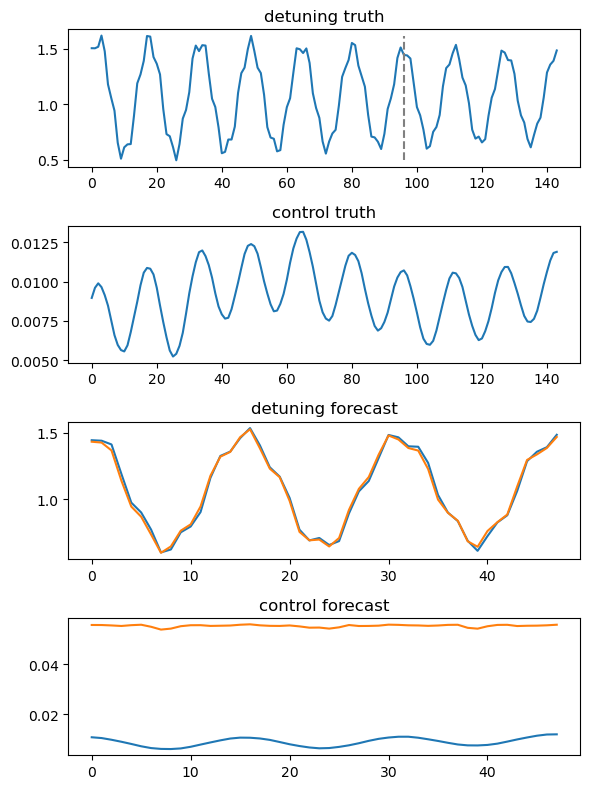

In [12]:
jdata = 0

policy.eval()
with torch.no_grad():
    for back, fore in test_loader:
        sa = back[[jdata]]
        sa_next = fore[[jdata]]
        sa_total = torch.cat([sa, sa_next], dim=1)

        model_output = model(sa)

        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)

        plt.figure(figsize=(6,8))

        sa_total_xmin = torch.min(sa_total[0, :, 0])
        sa_total_xmax = torch.max(sa_total[0, :, 0])
        plt.subplot(4,1,1)
        plt.title('detuning truth')
        plt.plot(sa_total[0, :, 0])
        plt.plot([96, 96], [sa_total_xmin, sa_total_xmax], color='gray', linestyle='dashed')

        plt.subplot(4,1,2)
        plt.title('control truth')
        plt.plot(sa_total[0, :, 1])

        plt.subplot(4,1,3)
        plt.title('detuning forecast')
        plt.plot(sa_next[0, :, 0])
        plt.plot(s_next[0, :, 0])

        plt.subplot(4,1,4)
        plt.title('control forecast')
        plt.plot(sa_next[0, : , 1])
        plt.plot(a_next[0, :, 0])

        plt.tight_layout()
        plt.show()
        break

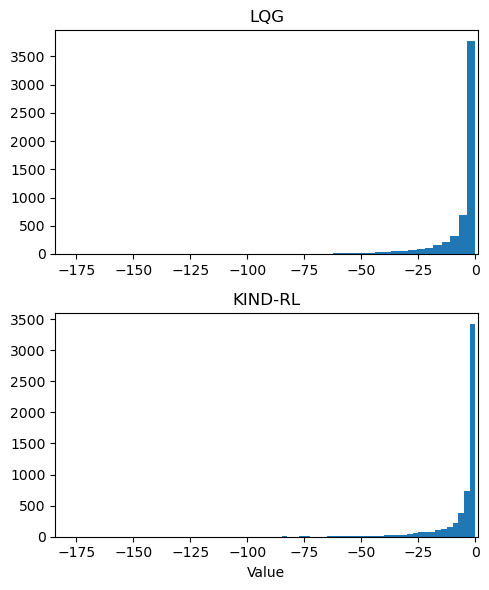

In [13]:
v_lqg = []
v_nn = []

policy.eval()

with torch.no_grad():
    for sa, sa_next in test_loader:
        v_lqg.append(return_fun(reward_fun(sa_next[:, :, :2])))

        model_output = model(sa)
        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)
        sa_next = torch.cat([s_next, a_next], dim=-1)
        v_nn.append(return_fun(reward_fun(sa_next)))

    v_lqg = torch.cat(v_lqg, dim=0)
    v_nn = torch.cat(v_nn, dim=0)

    plt.figure(figsize=(5,6))
    v_min = torch.min(v_lqg)

    plt.subplot(2,1,1)
    plt.title('LQG')
    plt.hist(v_lqg.flatten(), bins=50)
    plt.xlim((v_min, 1))

    plt.subplot(2,1,2)
    plt.title('KIND-RL')
    plt.hist(v_nn.flatten(), bins=50)
    plt.xlim((v_min, 1))
    plt.xlabel('Value')

    plt.tight_layout()
    plt.show()

#plt.scatter(detuning.flatten(), control.flatten(), alpha=0.2)

In [14]:
patience = 20
checkpoints = '../../models/delay/value'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.eval()
value_fun.train()

for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:

        s = sa[:, -48:, [0]]
        a = policy(s)

        s = sa[:, :, [0]]
        a = torch.cat([torch.zeros_like(a), a], dim=1)
        m = torch.zeros_like(a)
        m[:, -48:] = 1.
        sam = torch.cat([s, a, m], dim=-1)

        value_fun_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = 1 / r_max.ravel()

        v, target = evaluate_policy(sam, model, args, value_fun, gamma)
        criterion = torch.nn.L1Loss()

        loss = scaling * criterion(v, target)
        train_loss.append(loss.item())
        loss.backward()
        value_fun_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_value(model, valid_loader, args, value_fun, gamma)
    test_loss = validate_value(model, test_loader, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(value_fun, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
value_fun.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.132129, valid=0.478984, test=0.490258
	validation loss decreased (inf -> 0.478984), saving model ...
	epoch 2 losses: train=0.133398, valid=0.472970, test=0.484249
	validation loss decreased (0.478984 -> 0.472970), saving model ...
	epoch 3 losses: train=0.128772, valid=0.484310, test=0.496934
	early stopping counter: 1 out of 20
	epoch 4 losses: train=0.128037, valid=0.482213, test=0.495093
	early stopping counter: 2 out of 20
	epoch 5 losses: train=0.111587, valid=0.478396, test=0.489172
	early stopping counter: 3 out of 20
	epoch 6 losses: train=0.113040, valid=0.473842, test=0.484461
	early stopping counter: 4 out of 20
	epoch 7 losses: train=0.112293, valid=0.478190, test=0.490944
	early stopping counter: 5 out of 20
	epoch 8 losses: train=0.114069, valid=0.471190, test=0.482528
	validation loss decreased (0.472970 -> 0.471190), saving model ...
	epoch 9 losses: train=0.107234, valid=0.485383, test=0.498402
	early stopping counter: 1 out of 20
	epoch 10 lo

<All keys matched successfully>

In [15]:
patience = 20
checkpoints = '../../models/delay/policy'
early_stopping = utils_nn.early_stopping(patience=patience, checkpoint_path=checkpoints)

policy.train()
value_fun.eval()

for epoch in range(nepoch):
    train_loss = []

    for sa, _ in train_loader:
        policy_optim.zero_grad()

        max_state = torch.ones(1, state_ndim)
        max_action = torch.ones(1, action_ndim)
        r_max = (max_state @ state_cost @ max_state.T) + (max_action @ action_cost @ max_action.T)
        scaling = (1 - gamma) / r_max.ravel()

        loss = scaling * improve_policy(sa, model, policy, args, value_fun, gamma)

        train_loss.append(loss.item())
        loss.backward()
        policy_optim.step()

    train_loss = np.average(train_loss)
    valid_loss = validate_policy(policy, valid_loader, model, args, value_fun, gamma)
    test_loss = validate_policy(policy, test_loader, model, args, value_fun, gamma)

    print(f'\tepoch {epoch+1} losses: train={train_loss:.6f}, valid={valid_loss:.6f}, test={test_loss:.6f}')

    # --! use validation loss to check early stopping
    if early_stopping(policy, valid_loss):
        print("\tearly stopping ...")
        break

best_model_path = checkpoints + '/' + 'checkpoint.pth'
policy.load_state_dict(torch.load(best_model_path, weights_only=True))

	epoch 1 losses: train=0.185719, valid=2.466806, test=2.486505
	validation loss decreased (inf -> 2.466806), saving model ...
	epoch 2 losses: train=0.185767, valid=2.465104, test=2.487460
	validation loss decreased (2.466806 -> 2.465104), saving model ...
	epoch 3 losses: train=0.185683, valid=2.465916, test=2.488738
	early stopping counter: 1 out of 20
	epoch 4 losses: train=0.185646, valid=2.465781, test=2.488197
	early stopping counter: 2 out of 20
	epoch 5 losses: train=0.185634, valid=2.468175, test=2.489350
	early stopping counter: 3 out of 20
	epoch 6 losses: train=0.185634, valid=2.466931, test=2.488723
	early stopping counter: 4 out of 20
	epoch 7 losses: train=0.185602, valid=2.467724, test=2.488781
	early stopping counter: 5 out of 20
	epoch 8 losses: train=0.185527, valid=2.466854, test=2.489680
	early stopping counter: 6 out of 20
	epoch 9 losses: train=0.185579, valid=2.467095, test=2.488536
	early stopping counter: 7 out of 20
	epoch 10 losses: train=0.185598, valid=2.4

<All keys matched successfully>

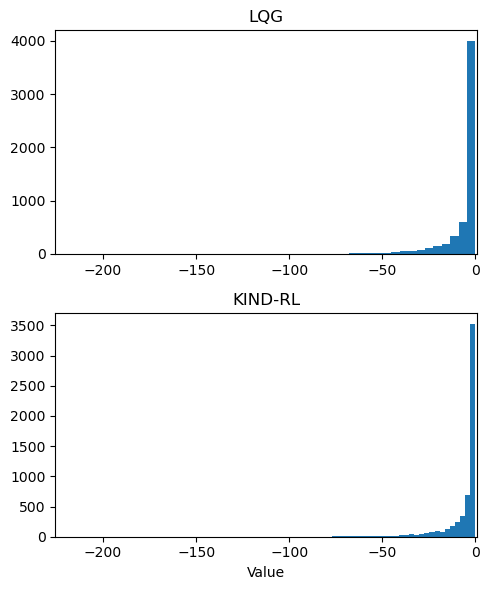

In [16]:
v_lqg = []
v_nn = []

policy.eval()

with torch.no_grad():
    for sa, sa_next in test_loader:
        v_lqg.append(return_fun(reward_fun(sa_next[:, :, :2])))

        model_output = model(sa)
        s_next = model_output[0][:, args.lookback_nsample:]
        a_next = policy(s_next)
        sa_next = torch.cat([s_next, a_next], dim=-1)
        v_nn.append(return_fun(reward_fun(sa_next)))

    v_lqg = torch.cat(v_lqg, dim=0)
    v_nn = torch.cat(v_nn, dim=0)

    plt.figure(figsize=(5,6))
    v_min = torch.min(v_lqg)

    plt.subplot(2,1,1)
    plt.title('LQG')
    plt.hist(v_lqg.flatten(), bins=50)
    plt.xlim((v_min, 1))

    plt.subplot(2,1,2)
    plt.title('KIND-RL')
    plt.hist(v_nn.flatten(), bins=50)
    plt.xlim((v_min, 1))
    plt.xlabel('Value')

    plt.tight_layout()
    plt.show()